<a href="https://colab.research.google.com/github/np03cs4a240301-sudo/ConceptandTechnologyofAI/blob/main/Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.feature_selection import RFE


In [ ]:
df = pd.read_csv("Classification.csv")
# printing first 10 row
df.head(10)

,Series Name,Country Name,2000,2001,2002,2003,2004,2005,2006,2007,...,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023
0,"Adolescent fertility rate (births per 1,000 wo...",Afghanistan,154.31,152.471,150.161,143.75,136.93,130.838,121.635,117.754,...,84.069,81.043,78.13,75.3,73.021,70.967,68.877,66.599,65.339,64.068
1,"Adolescent fertility rate (births per 1,000 wo...",Albania,14.743,8.811,13.511,15.889,17.662,18.216,16.517,15.882,...,21.767,20.656,18.518,16.778,15.456,14.949,14.004,13.002,12.827,12.789
2,"Adolescent fertility rate (births per 1,000 wo...",Algeria,8.658,8.065,7.74,7.727,7.789,7.87,8.403,8.795,...,10.196,10.294,10.5,9.978,9.495,10.328,9.901,9.343,8.977,8.698
3,"Adolescent fertility rate (births per 1,000 wo...",American Samoa,48.376,46.153,44.466,42.685,41.905,38.191,35.852,33.607,...,43.059,42.174,39.45,37.274,35.427,34.278,34.149,34.214,34.104,34.181
4,"Adolescent fertility rate (births per 1,000 wo...",Andorra,9.075,9.84,9.384,8.335,8.712,9.064,9.383,9.034,...,4.947,4.936,4.576,4.326,3.832,3.526,3.119,3.5,3.527,3.48
5,"Adolescent fertility rate (births per 1,000 wo...",Angola,147.693,147.253,150.196,152.242,155.118,157.066,158.737,159.675,...,151.577,150.244,148.905,147.407,146.305,145.094,144.329,143.383,141.978,140.84
6,"Adolescent fertility rate (births per 1,000 wo...",Antigua and Barbuda,61.851,59.991,56.432,53.866,51.976,50.109,48.992,49.104,...,34.168,35.946,31.44,31.069,28.173,31.691,33.916,33.751,33.469,32.932
7,"Adolescent fertility rate (births per 1,000 wo...",Argentina,65.808,63.491,62.126,60.002,61.681,63.546,64.156,64.562,...,66.613,63.879,58.79,55.022,49.926,41.751,31.492,28.54,25.767,26.414
8,"Adolescent fertility rate (births per 1,000 wo...",Armenia,37.273,33.063,32.184,32.048,32.104,30.055,28.542,27.88,...,25.716,25.103,24.38,21.153,18.657,16.328,13.735,13.66,13.487,13.445
9,"Adolescent fertility rate (births per 1,000 wo...",Aruba,43.729,40.463,38.185,37.807,38.761,40.121,41.03,40.863,...,34.863,32.348,30.102,27.289,24.049,22.123,20.554,18.615,18.768,18.788


In [ ]:
row,column= df.shape
print("row:",row)
print("Column:",column)

row: 23870
Column: 26


In [ ]:
print(df.head())

print(df.info())
print(df.describe())
print(df.isnull().sum().head())
print(df.tail())



                                         Series Name    Country Name    2000  \
0  Adolescent fertility rate (births per 1,000 wo...     Afghanistan  154.31   
1  Adolescent fertility rate (births per 1,000 wo...         Albania  14.743   
2  Adolescent fertility rate (births per 1,000 wo...         Algeria   8.658   
3  Adolescent fertility rate (births per 1,000 wo...  American Samoa  48.376   
4  Adolescent fertility rate (births per 1,000 wo...         Andorra   9.075   

      2001     2002    2003    2004     2005     2006     2007  ...    2014  \
0  152.471  150.161  143.75  136.93  130.838  121.635  117.754  ...  84.069   
1    8.811   13.511  15.889  17.662   18.216   16.517   15.882  ...  21.767   
2    8.065     7.74   7.727   7.789     7.87    8.403    8.795  ...  10.196   
3   46.153   44.466  42.685  41.905   38.191   35.852   33.607  ...  43.059   
4     9.84    9.384   8.335   8.712    9.064    9.383    9.034  ...   4.947   

     2015    2016    2017    2018    2019   

In [ ]:
# checking the columns
df.columns


Index(['Series Name', 'Country Name', '2000', '2001', '2002', '2003', '2004',
       '2005', '2006', '2007', '2008', '2009', '2010', '2011', '2012', '2013',
       '2014', '2015', '2016', '2017', '2018', '2019', '2020', '2021', '2022',
       '2023'],
      dtype='object')

In [ ]:
# check the value count of Air Quality
df['Country Name'].value_counts()

,count
Country Name,
Afghanistan,110
Albania,110
Algeria,110
American Samoa,110
Andorra,110
...,...
Virgin Islands (U.S.),110
West Bank and Gaza,110
"Yemen, Rep.",110


In [ ]:

# checking the value counts
print(df.isnull().sum())


Series Name     0
Country Name    0
2000            0
2001            0
2002            0
2003            0
2004            0
2005            0
2006            0
2007            0
2008            0
2009            0
2010            0
2011            0
2012            0
2013            0
2014            0
2015            0
2016            0
2017            0
2018            0
2019            0
2020            0
2021            0
2022            0
2023            0
dtype: int64


In [ ]:
indicator = "Adolescent fertility rate (births per 1,000 women ages 15-19)"
sub = df[df["Series Name"] == indicator].copy()

# Convert year columns to numeric
year_cols = sub.columns[4:]
sub.loc[:, year_cols] = sub[year_cols].apply(pd.to_numeric, errors='coerce')

# Create binary target variable
sub["target"] = (sub[year_cols].mean(axis=1) > sub[year_cols].mean().mean()).astype(int)




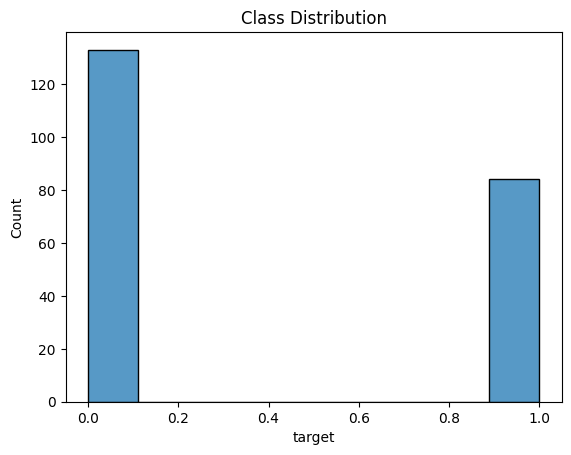

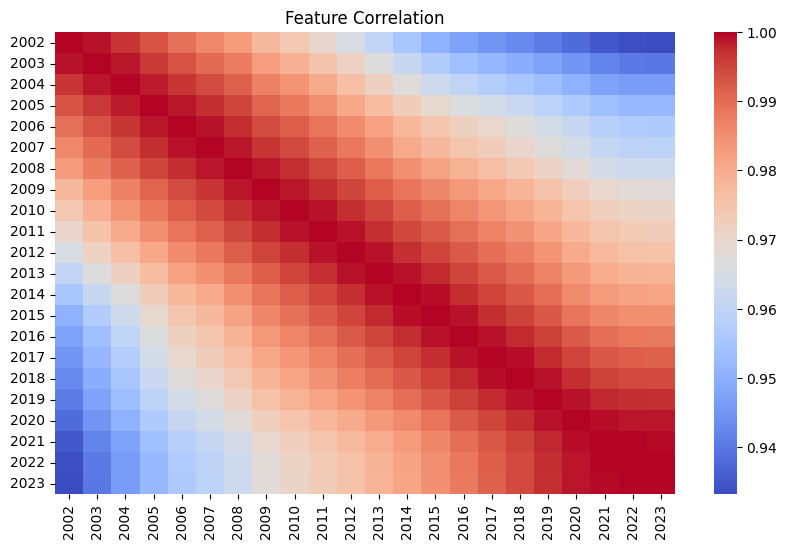

In [ ]:
# Class distribution visualization
sns.histplot(sub["target"])
plt.title("Class Distribution")
plt.show()

# Correlation heatmap
plt.figure(figsize=(10,6))
sns.heatmap(sub[year_cols].corr(), cmap="coolwarm")
plt.title("Feature Correlation")
plt.show()




In [ ]:
# Neural Network (MLP)
mlp = MLPClassifier(hidden_layer_sizes=(50,), max_iter=500, random_state=42)
mlp.fit(X_train, y_train)
y_pred_mlp = mlp.predict(X_test)

print("\nNeural Network (MLP) Performance:")
print("Accuracy:", accuracy_score(y_test, y_pred_mlp))
print("Precision:", precision_score(y_test, y_pred_mlp))
print("Recall:", recall_score(y_test, y_pred_mlp))
print("F1 Score:", f1_score(y_test, y_pred_mlp))


Neural Network (MLP) Performance:
Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1 Score: 1.0


In [ ]:
# Features and target
X = sub[year_cols].fillna(sub[year_cols].mean())
y = sub["target"]

# Feature selection with RFE
model = LogisticRegression(max_iter=1000)
rfe = RFE(model, n_features_to_select=5)
rfe.fit(X, y)
selected_features = X.columns[rfe.support_]
print("Selected Features:", selected_features)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X[selected_features], y, test_size=0.2, random_state=42
)

# Standardization
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)



/tmp/ipython-input-3068866800.py:2: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  X = sub[year_cols].fillna(sub[year_cols].mean())


Selected Features: Index(['2003', '2005', '2015', '2016', '2017'], dtype='object')


In [ ]:
# performing evaluation
from sklearn.metrics import accuracy_score,classification_report, confusion_matrix
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Logistic Regression
lr = LogisticRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

print("Logistic Regression Performance:")
print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print("Precision:", precision_score(y_test, y_pred_lr))
print("Recall:", recall_score(y_test, y_pred_lr))
print("F1 Score:", f1_score(y_test, y_pred_lr))


# Classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred_lr))


#average='macro' calculates the metric for each class separately and then takes the average, treating all classes equally.
conf_matrix = confusion_matrix(y_test, y_pred_lr)
print("Confusion Matrix:\n", conf_matrix)




Logistic Regression Performance:
Accuracy: 0.9772727272727273
Precision: 1.0
Recall: 0.9444444444444444
F1 Score: 0.9714285714285714

Classification Report:
              precision    recall  f1-score   support

           0       0.96      1.00      0.98        26
           1       1.00      0.94      0.97        18

    accuracy                           0.98        44
   macro avg       0.98      0.97      0.98        44
weighted avg       0.98      0.98      0.98        44

Confusion Matrix:
 [[26  0]
 [ 1 17]]


Hyperparameter

In [ ]:

# Logistic Regression GridSearch
param_grid_lr = {
    'C': [0.01, 0.1, 1, 10],
    'solver': ['liblinear', 'lbfgs']
}
grid_lr = GridSearchCV(LogisticRegression(max_iter=1000), param_grid_lr, cv=5)
grid_lr.fit(X_train, y_train)
best_lr = grid_lr.best_estimator_
print("Best Logistic Regression Params:", grid_lr.best_params_)
print("Best CV score: ",grid_Search.best_score_)

# return the model with best hyperparameter

best_model = grid_Search.best_estimator_
print(best_model)

y_pred = best_model.predict(X_test)
print("Test Accuracy:", accuracy_score(y_test, y_pred))

Best Logistic Regression Params: {'C': 10, 'solver': 'liblinear'}
Best CV score:  1.0
LogisticRegression(C=10, solver='liblinear')
Test Accuracy: 1.0


In [ ]:

from sklearn.feature_selection import RFE
# re trainning the logistic model with optimized c value
log_reg_best = LogisticRegression(
    C=10,
    penalty='l2',
    solver='lbfgs',
    max_iter=5000,
    random_state=42
)

rfe = RFE(estimator=best_model, n_features_to_select=5)

# Fit on training data
X_train_selected = rfe.fit_transform(X_train, y_train)


X_test_selected = rfe.transform(X_test)

print("Selected Features:", rfe.support_)
print("Feature Ranking:", rfe.ranking_)

Selected Features: [ True  True  True  True  True]
Feature Ranking: [1 1 1 1 1]


In [ ]:
ReBuild_RFE= LogisticRegression(
    C=10,
    penalty='l2',
    solver='lbfgs',
    max_iter=5000,
    random_state=42


)
ReBuild_RFE.fit(X_train_selected,y_train)
y_pred_rfe= ReBuild_RFE.predict(X_test_selected)


print("Accuracy after feature selection and hyper parameter tuning :", accuracy_score(y_test, y_pred_rfe))
print("Precision:", precision_score(y_test, y_pred_rfe, average='macro'))
print("Recall:", recall_score(y_test, y_pred_rfe, average='macro'))
print("F1 Score:", f1_score(y_test, y_pred_rfe, average='macro'))

Accuracy after feature selection and hyper parameter tuning : 1.0
Precision: 1.0
Recall: 1.0
F1 Score: 1.0


In [ ]:
# Decision Tree
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)

print("\nDecision Tree Performance:")
print("Accuracy:", accuracy_score(y_test, y_pred_dt))
print("Precision:", precision_score(y_test, y_pred_dt))
print("Recall:", recall_score(y_test, y_pred_dt))
print("F1 Score:", f1_score(y_test, y_pred_dt))


# Classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred_dt))

#average='macro' calculates the metric for each class separately and then takes the average, treating all classes equally.
conf_matrix = confusion_matrix(y_test, y_pred_dt)
print("Confusion Matrix:\n", conf_matrix)


Decision Tree Performance:
Accuracy: 0.9545454545454546
Precision: 0.9444444444444444
Recall: 0.9444444444444444
F1 Score: 0.9444444444444444

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.96      0.96        26
           1       0.94      0.94      0.94        18

    accuracy                           0.95        44
   macro avg       0.95      0.95      0.95        44
weighted avg       0.95      0.95      0.95        44

Confusion Matrix:
 [[25  1]
 [ 1 17]]


In [ ]:
# Decision Tree GridSearch
param_grid_dt = {
    'max_depth': [3, 5, 10, None],
    'min_samples_split': [2, 5, 10]
}
grid_dt = GridSearchCV(DecisionTreeClassifier(random_state=42), param_grid_dt, cv=5)
grid_dt.fit(X_train, y_train)
best_dt = grid_dt.best_estimator_
print("Best Decision Tree Params:", grid_dt.best_params_)
print("Best CV score:", grid_dt.best_score_)
best_model = grid_dt.best_estimator_
print(best_model)


Best Decision Tree Params: {'max_depth': 3, 'min_samples_split': 5}
Best CV score: 0.9710924369747899
DecisionTreeClassifier(max_depth=3, min_samples_split=5, random_state=42)


In [ ]:
from sklearn.feature_selection import RFE

# Step 1: Define RFE with the tuned best_model
rfe_dt = RFE(estimator=best_model, n_features_to_select=5)

# Step 2: Fit RFE on training data
rfe_dt.fit(X_train, y_train)

# Step 3: Transform both train and test sets
X_train_selected_rf = rfe_dt.transform(X_train)
X_test_selected_rf = rfe_dt.transform(X_test)

print("Selected Features (RFE with Tuned Model):", rfe_dt.support_)
print("Feature Ranking (RFE with Tuned Model):", rfe_dt.ranking_)

Selected Features (RFE with Tuned Model): [ True  True  True  True  True]
Feature Ranking (RFE with Tuned Model): [1 1 1 1 1]


In [ ]:
# Convert to DataFrame for comparison
results_df = pd.DataFrame(results)
print("\nFinal Model Comparison:\n", results_df)



Final Model Comparison:
                          Model  Accuracy  Precision    Recall  F1-Score
0  Logistic Regression (Tuned)  1.000000   1.000000  1.000000  1.000000
1        Decision Tree (Tuned)  0.954545   0.944444  0.944444  0.944444
2         Neural Network (MLP)  1.000000   1.000000  1.000000  1.000000
